In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.graphics.mosaicplot as mosaic
from scipy import stats
import collections

rng = np.random.default_rng()

In [3]:
gens = pd.read_csv("../data/gens_good.csv", decimal='.', delimiter=',')
gens.head()

,Nn,C-4G,C-4,C-6G,C-6
0,c1,TT,1.4,CC,1.1
1,c2,CT,1.6,CT,0.6
2,c3,CT,1.4,CC,1.1
3,c4,CT,1.5,CC,0.7
4,c5,CT,1.5,CC,0.9


In [4]:
diets = pd.read_csv("../data/diets.csv", decimal='.', delimiter=',')
diets.head()

,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
0,25,NaN,41,171,60,2,60.0
1,26,NaN,32,174,103,2,103.0
2,1,0.0,22,159,58,1,54.2
3,2,0.0,46,192,60,1,54.0
4,3,0.0,55,170,64,1,63.3


$p$-value меньше - отвергаем $H_0$

# Block 2

## 1. Prac 3

##### 1. Для данных gens проверьте гипотезы (используйте t-критерий Стьюдента с поправкой Уэлча и без неё):
* Среднее C-4 не отличается для здоровых пациентов (Nn=c1-c60) и пациентов с диагнозом;
* Среднее C-6 не отличается для здоровых пациентов (Nn=c1-c60) и пациентов с диагнозом;
* Проанализируйте результаты тестирования. Ответьте на вопрос: какой вариант t-теста корректно применять для предложенных данных?
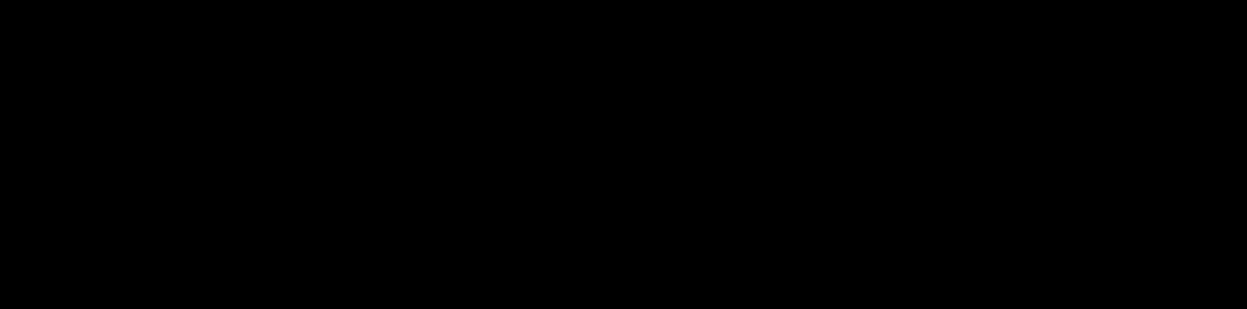

In [5]:
gens_healthy = gens[:60]
gens_healthy.tail()

,Nn,C-4G,C-4,C-6G,C-6
55,c56,TT,1.6,CC,1.6
56,c57,TT,1.6,CC,0.9
57,c58,CT,1.4,CC,1.4
58,c59,CC,1.6,CT,1.7
59,c60,TT,1.7,CT,1.3


In [6]:
gens_ill = gens[60:]
gens_ill

,Nn,C-4G,C-4,C-6G,C-6
60,a1,CC,8.4,TT,1.2
61,a2,CC,6.4,CT,3.1
62,a3,CT,6.7,CT,6.3
63,a4,CC,7.7,CT,2.4
64,a5,CT,8.7,CT,0.6
...,...,...,...,...,...
205,vr31,CT,6.7,TT,1.1
206,vr32,CT,6.7,TT,2.3
207,vr33,CT,5.4,CT,1.2
208,vr34,CT,7.8,TT,1.2


 $H_0$: $\mu_h = \mu_i$

In [7]:
print("Classic; Whelch")
stats.ttest_ind(gens_healthy["C-4"], gens_ill["C-4"]), stats.ttest_ind(gens_healthy["C-4"], gens_ill["C-4"],
                                                                       equal_var=False)

Classic; Whelch


(TtestResult(statistic=np.float64(-17.10625976922609), pvalue=np.float64(1.537771425110328e-41), df=np.float64(208.0)),
 TtestResult(statistic=np.float64(-26.931820480358162), pvalue=np.float64(6.043467899788593e-60), df=np.float64(153.03932511334793)))

In [8]:
print("Classic; Whelch")
stats.ttest_ind(gens_healthy["C-6"], gens_ill["C-6"]), stats.ttest_ind(gens_healthy["C-6"], gens_ill["C-6"],
                                                                       equal_var=False)

Classic; Whelch


(TtestResult(statistic=np.float64(-6.596018605139031), pvalue=np.float64(3.429984637564943e-10), df=np.float64(208.0)),
 TtestResult(statistic=np.float64(-9.49778656678844), pvalue=np.float64(6.392250245665488e-18), df=np.float64(201.94401543110573)))

##### 2.	Используя данные по эффективности диет, ответьте на вопрос, помогают ли диеты уменьшить ИМТ?
* ИМТ = $ \frac{ \text{вес} ( \text{кг} ) }{ \text{рост}^2 ( \text{м}^2 ) } $

In [9]:
imt_pre = diets["pre.weight"] / diets["Height"] ** 2
imt_post = diets["weight6weeks"] / diets["Height"] ** 2

In [10]:
stats.ttest_rel(imt_pre, imt_post)

TtestResult(statistic=np.float64(12.763815045839104), pvalue=np.float64(1.0875669507287134e-20), df=np.int64(77))

## 2. Prac 4

##### 1.	Для данных gens проверьте гипотезы (используйте непараметрические тесты):
* Медиана C-4 не отличается для здоровых пациентов (Nn=c1-c60) и пациентов с диагнозом;
* Медиана C-6 не отличается для здоровых пациентов (Nn=c1-c60) и пациентов с диагнозом;
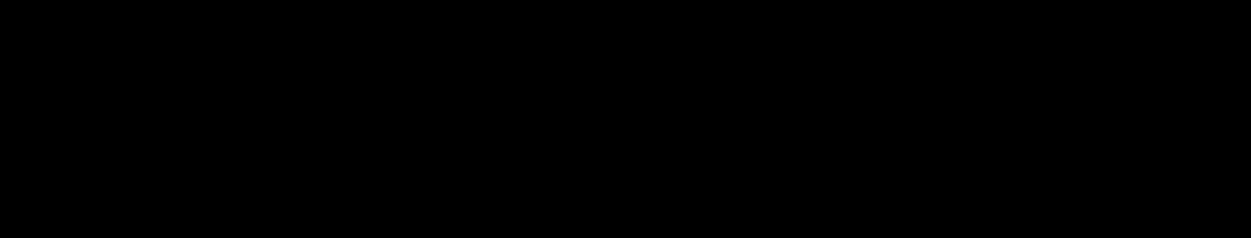

In [11]:
gens_healthy[["C-4", "C-6"]].median(), gens_ill[["C-4", "C-6"]].median()

(C-4    1.5
 C-6    1.1
 dtype: float64,
 C-4    6.4
 C-6    1.9
 dtype: float64)

C-4

In [13]:
# Mann-Whitney U
stats.mannwhitneyu(gens_healthy["C-4"], gens_ill["C-4"])

MannwhitneyuResult(statistic=np.float64(464.0), pvalue=np.float64(2.7560712453288822e-24))

In [12]:
stats.median_test(gens_healthy["C-4"], gens_ill["C-4"])

MedianTestResult(statistic=np.float64(76.63446350762527), pvalue=np.float64(2.0571812820535518e-18), median=np.float64(5.4), table=array([[  0, 102],
       [ 60,  48]]))

C-6

In [16]:
stats.mannwhitneyu(gens_healthy["C-6"], gens_ill["C-6"])

MannwhitneyuResult(statistic=np.float64(1892.0), pvalue=np.float64(4.8481465889014486e-11))

In [15]:
stats.median_test(gens_healthy["C-6"], gens_ill["C-6"])

MedianTestResult(statistic=np.float64(31.497615587246802), pvalue=np.float64(1.9968531405134384e-08), median=np.float64(1.6), table=array([[10, 91],
       [50, 59]]))

##### 2. Можно ли считать эти данные нормально-распределёнными? Для ответа на вопрос используйте графические и формальные критерии.

$H_0$: $F \approx N$

In [38]:
len(gens_healthy), len(gens_ill)

(60, 150)

In [19]:
stats.shapiro(gens_healthy["C-4"]), stats.shapiro(gens_healthy["C-6"])

(ShapiroResult(statistic=np.float64(0.9364977561154829), pvalue=np.float64(0.0037879867414377724)),
 ShapiroResult(statistic=np.float64(0.9643537023200703), pvalue=np.float64(0.07696666886981474)))

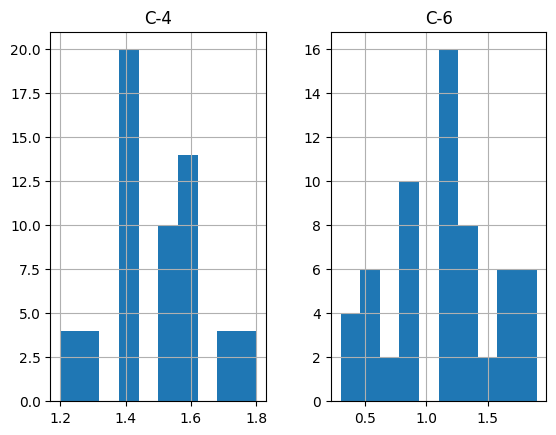

In [20]:
gens_healthy[["C-4", "C-6"]].hist()
plt.show()

In [21]:
stats.shapiro(gens_ill["C-4"]), stats.shapiro(gens_ill["C-6"])

(ShapiroResult(statistic=np.float64(0.9293032656373877), pvalue=np.float64(8.881027919361326e-07)),
 ShapiroResult(statistic=np.float64(0.9092368499263335), pvalue=np.float64(4.5513358632007625e-08)))

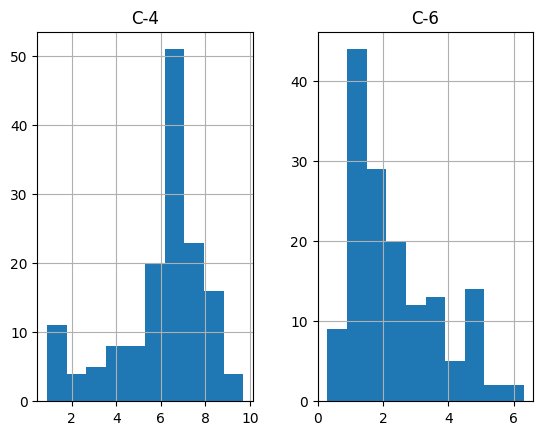

In [22]:
gens_ill[["C-4", "C-6"]].hist()
plt.show()

##### 3.	Какие тесты (параметрические или непараметрические) правомерно использовать для проверки гипотез о равенстве центральных тенденций этих данных?

Количество данных достаточно для применения параметрических тестов, однако тест на нормальность показывает, что данные отличаются от нормального распределения, поэтому лучше применять непараметрические тесты.

## 3. Prac 5

##### 1.	Используя данные по своей группе, ответьте на вопрос: отличается ли соотношение полов в группе от 1:1 и значимо ли это отличие (если отличается)?

In [23]:
m_count = 28
f_count = 4
total = m_count + f_count

In [24]:
eq = total / 2

In [25]:
chi2 = (m_count - eq) ** 2 / eq + (f_count - eq) ** 2 / eq
chi2

18.0

In [26]:
1 - stats.chi2.cdf(chi2, df=1)

np.float64(2.2090496998639075e-05)

In [27]:
stats.chi2.ppf(0.95, df=1)

np.float64(3.841458820694124)

In [28]:
stats.chisquare([m_count, f_count])

Power_divergenceResult(statistic=np.float64(18.0), pvalue=np.float64(2.2090496998585475e-05))

##### 2.	Т. Бишоп (Т. Bishop. High frequency neural modulation in dentistry. J. Am. Dent. Assoc., 112:176—177, 1986) изучил эффективность высокочастотной стимуляции нерва в качестве обезболивающего средства при удалении зуба. Все больные подключались к прибору, но в одних случаях он работал, в других был выключен. Ни стоматолог, ни больной не знали, включен ли прибор.
Позволяют ли следующие данные считать высокочастотную стимуляцию нерва действенным анальгезирующим средством?

|           | Вкл  | Выкл |
|-----------|------|------|
| Боли нет  | 24   | 3    |
| Боли есть | 6    | 17   |

In [29]:
table_teeth = np.array([
    [24, 3],
    [6, 17]
])
row_sum = table_teeth.sum(-1)
col_sum = table_teeth.sum(0)
total_sum = table_teeth.sum()
row_sum, col_sum, total_sum

(array([27, 23]), array([30, 20]), np.int64(50))

$H_0$: работа прибора не влияет на боль

In [30]:
expected_table = col_sum * row_sum[:, None] / total_sum
expected_table

array([[16.2, 10.8],
       [13.8,  9.2]])

In [31]:
chi2_teeth = (table_teeth - expected_table) ** 2 / expected_table
chi2_teeth = chi2_teeth.sum()
chi2_teeth

np.float64(20.410628019323674)

In [32]:
1 - stats.chi2.cdf(chi2_teeth, df=1)

np.float64(6.248183180179723e-06)

In [33]:
stats.chi2_contingency(table_teeth, correction=False)

Chi2ContingencyResult(statistic=np.float64(20.410628019323674), pvalue=np.float64(6.248183180141306e-06), dof=1, expected_freq=array([[16.2, 10.8],
       [13.8,  9.2]]))

With correction (используют, если некоторые ожидаемые частоты $<10$)

In [34]:
chi2_teeth_cor = (np.abs(table_teeth - expected_table) - 0.5) ** 2 / expected_table
1 - stats.chi2.cdf(chi2_teeth_cor.sum(), df=1)

np.float64(2.355589788338719e-05)

In [35]:
stats.chi2_contingency(table_teeth, correction=True)

Chi2ContingencyResult(statistic=np.float64(17.877750939345148), pvalue=np.float64(2.3555897883376798e-05), dof=1, expected_freq=array([[16.2, 10.8],
       [13.8,  9.2]]))

Капча

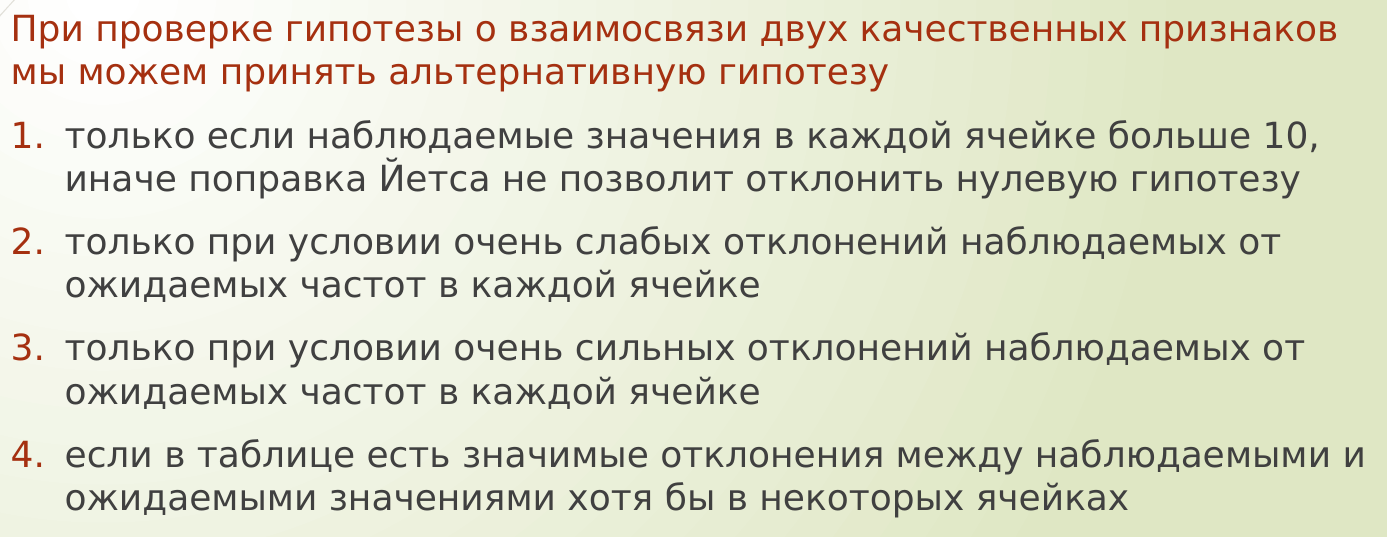

##### 3.	А. О’Нил и соавт. (A. O’Neil et al. A waterborn epidemic of acute infectious non-bacterial gastroenteritis in Alberta, Canada. Can. J. Public Health, 76:199—203, 1985) сообщили о вспышке гастроэнтерита в маленьком канадском городке.
Исследователи предположили, что источником инфекции была водопроводная вода. Они исследовали зависимость между количеством выпитой воды и числом заболевших. Какие выводы можно сделать из приводимых данных?

| Кол-во выпитой воды (ст/день) | Число заболевших | Число не заболевших |
|-------------------------------|------------------|---------------------|
| < 1                           | 39               | 121                 |
| 1-4                           | 264              | 258                 |
| >= 5                          | 265              | 146                 |

In [36]:
water_table = np.array([
    [39, 121],
    [264, 258],
    [265, 146]
])

$H_0$: вода не влияет на заболевание

In [37]:
stats.chi2_contingency(water_table, correction=True)

Chi2ContingencyResult(statistic=np.float64(74.97331788461106), pvalue=np.float64(5.245065021330482e-17), dof=2, expected_freq=array([[ 83.14730101,  76.85269899],
       [271.26806953, 250.73193047],
       [213.58462946, 197.41537054]]))